# Showcase of Girvan-Newman algorithm implementation
In the following Notebook, we showcase our implementation of the Girvan-Newman algorithm using different datasets. We will also make a performance evaluation against random graphs and make comparisons with a known library for graphs manipulation: NetworkX.
##### Authors: Kerserliss, EllynaSoumelis, Egeyae

### Imports
---

In [1]:
from girvannewman import girvannewman
from performance_evaluation import test_method
from loader import load_karate, load_college_football
import matplotlib.pyplot as plt


colors = [
    '#FFD1DC',
    '#FFFFB4',
    '#B4FFB4',
    '#B4FFE5',
    '#B4D1FF',
    '#D1B4FF',
    '#FFB4D1',
    '#E5FFB4',
    '#B4FFFF'
]

## 1. Karate dataset
---

In the following cells, we showcase the results on the Karate dataset

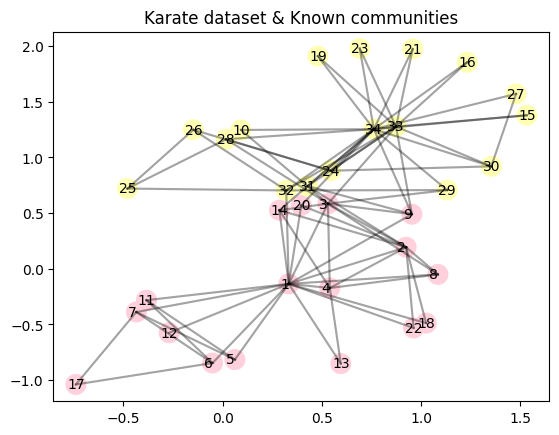

In [2]:
karate_graph, karate_known_communities = load_karate()
karate_colors = {}

for i, com in karate_known_communities.items():
    for v in com:
        karate_colors[v] = colors[(int(i)-1)%len(colors)]

karate_graph.plot(labels=True, title="Karate dataset & Known communities", colors=[karate_colors[v] for v in karate_graph.vertices])

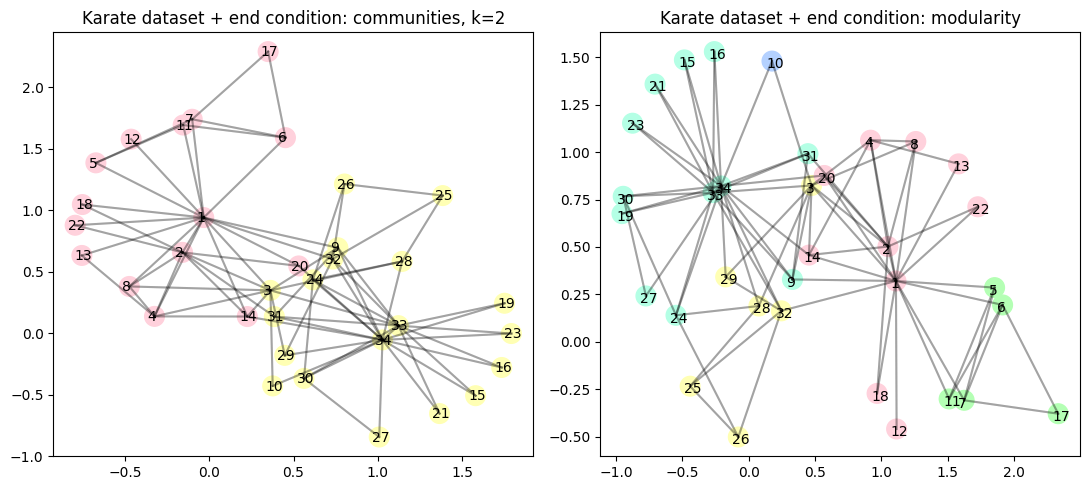

In [3]:
karate_k2_communities = girvannewman(karate_graph, method="communities", k=2)
karate_modularity_communities, _ = girvannewman(karate_graph, method="modularity")

k2_colors = {}
for i, com in enumerate(karate_k2_communities):
    for v in com:
        k2_colors[v] = colors[i%len(colors)]

mod_colors = {}
for i, com in enumerate(karate_modularity_communities):
    for v in com:
        mod_colors[v] = colors[i%len(colors)]
        

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
karate_graph.plot(ax=ax1, show=False, title="Karate dataset + end condition: communities, k=2", colors=[k2_colors[v] for v in karate_graph.vertices], labels=True)
karate_graph.plot(ax=ax2, show=False, title="Karate dataset + end condition: modularity", colors=[mod_colors[v] for v in karate_graph.vertices], labels=True)
plt.tight_layout()
plt.show()